# Introduction to Generative AI

Most artificial intelligence systems you encounter daily are built to **predict** or **classify** — is this email spam, what object is in this photo, will this customer churn. **Generative AI** takes a different approach: instead of assigning a label to existing data, it **creates new data** that resembles what it learned during training. A generative model can write an essay, compose music, generate an image from a text description, or produce code from a natural language prompt.

This capability has transformed how people interact with software. Chat assistants answer questions in natural language. Image tools create artwork from brief descriptions. Coding assistants suggest and complete programs. These systems synthesize outputs token by token, pixel by pixel, or sample by sample, guided by learned statistical patterns.

This notebook introduces the **basics** of generative AI: what it is, how it relates to machine learning and deep learning, how the field evolved, and what types of models and modalities exist. Mathematical foundations, specific architectures, and language model mechanics are covered in the notebooks that follow.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
np.random.seed(7)
plt.style.use("seaborn-v0_8-whitegrid")

---

## 1. What Is Generative AI?

**Generative AI** refers to a class of machine learning models that learn the underlying **distribution** of training data and use that knowledge to produce **new samples**. A model trained on millions of photographs learns what realistic images look like — their colors, textures, compositions — and can then generate novel images that follow the same statistical patterns.

The defining characteristic is **synthesis**. A spam classifier takes an email and outputs *spam* or *not spam*. A generative model takes a prompt or random seed and outputs a complete email, image, or audio clip that did not exist before.

Generation is inherently **probabilistic**. Given the same prompt, a generative model may produce different outputs each time because it samples from a learned probability distribution rather than computing a single deterministic answer. This variability enables creativity and diversity, but also means outputs can be inconsistent or incorrect.

Generative AI spans multiple data types:

- **Text** — essays, code, dialogue, translations
- **Images** — artwork, product mockups, photo editing
- **Audio** — speech synthesis, music composition
- **Video** — animation, scene generation
- **Structured data** — synthetic tabular records for privacy-preserving analysis

---

## 2. Generative AI in the Broader AI Landscape

Generative AI sits within the larger hierarchy of artificial intelligence and deep learning. Understanding where it fits clarifies how it relates to the concepts covered in AI Foundations.

```
┌─────────────────────────────────────────────────────────────┐
│              ARTIFICIAL INTELLIGENCE (AI)                   │
│  ┌───────────────────────────────────────────────────────┐  │
│  │           MACHINE LEARNING (ML)                       │  │
│  │  ┌─────────────────────────────────────────────────┐  │  │
│  │  │         DEEP LEARNING (DL)                      │  │  │
│  │  │  ┌───────────────────────────────────────────┐  │  │  │
│  │  │  │      GENERATIVE AI                        │  │  │  │
│  │  │  │  (GANs, diffusion, LLMs, multimodal)      │  │  │  │
│  │  │  └───────────────────────────────────────────┘  │  │  │
│  │  └─────────────────────────────────────────────────┘  │  │
│  └───────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────┘
```

Not all machine learning is generative. **Discriminative models** learn to distinguish between categories or predict numerical values. **Generative models** learn to model the data itself. Both are subsets of deep learning when implemented with neural networks, and both fall under the umbrella of AI.

Generative AI builds directly on foundations from earlier notebooks: neural networks and backpropagation (Deep Learning), sequence modeling and language models (NLP), probability and statistics (Mathematics), and the transformer architecture (Transfer Learning and Transformers).

---

## 3. Machine Learning and Generative AI

Generative AI is not a separate field from machine learning — it is a **learning objective** within ML. The same training loop applies: gather data, choose a model, define a loss function, optimize parameters, evaluate results.

### 3.1 Different Objectives, Same Framework

| ML Paradigm | What the Model Learns | Example |
|-------------|----------------------|--------|
| **Supervised (discriminative)** | $P(y \mid x)$ — label given features | Spam classification |
| **Unsupervised (generative)** | $P(x)$ — data distribution | Image synthesis |
| **Self-supervised (generative)** | $P(x_t \mid x_{<t})$ — next element given context | Language model pre-training |

Modern large language models use **self-supervised learning**: they create their own labels by predicting the next token in a sentence. No human annotation is required for pre-training — the structure of text itself provides the training signal.

### 3.2 From Prediction to Generation

In traditional supervised learning, the output space is fixed and finite (spam/ham, cat/dog/bird). In generative learning, the output space is the entire domain of possible data — every valid sentence, every plausible image. The model must capture enough of this space to produce convincing samples.

This is why generative models are typically **larger** and require **more data** than discriminative models for a comparable task. Modeling an entire distribution is harder than drawing a decision boundary.

### 3.3 Deep Learning as the Enabler

Before deep learning, generative models used explicit probability distributions (Gaussian mixtures, hidden Markov models) that could not capture the complexity of natural images or language. Neural networks — with millions or billions of parameters — can approximate arbitrarily complex distributions, making high-quality generation possible.

The progression in AI Foundations — from classical ML to deep learning to transformers — is the same progression that enabled modern generative AI.

---

## 4. Generative AI Evolution

Generative modeling has evolved through distinct eras, each unlocking new capabilities.

### 4.1 Statistical Era (1950s–2000s)

Early generative models used hand-designed probability distributions. **N-gram language models** estimated word probabilities from text counts. **Hidden Markov Models** generated speech sequences. **Gaussian Mixture Models** represented data as combinations of simple distributions. These worked for narrow domains but could not capture the complexity of natural images or open-ended language.

### 4.2 Deep Generative Era (2013–2019)

Neural networks brought generative modeling to high-dimensional data:

- **2013 — Variational Autoencoders (VAEs):** Learned compressed latent representations; established the encoder-decoder framework.
- **2014 — Generative Adversarial Networks (GANs):** Introduced adversarial training with generator and discriminator networks; produced sharp, realistic images.
- **2018 — GPT-1:** Demonstrated that transformer-based autoregressive models could generate coherent text at scale.

### 4.3 Transformer and Scale Era (2019–2022)

The transformer architecture and massive scaling changed what was possible:

- **2019 — GPT-2:** Showed emergent text generation capabilities with 1.5B parameters.
- **2020 — GPT-3:** 175B parameters; few-shot prompting became practical without fine-tuning.
- **2021 — DALL-E, Codex:** Text-to-image and code generation reached mainstream quality.
- **2022 — ChatGPT, Stable Diffusion:** Accessible generative tools for the general public.

### 4.4 Current Era (2023–present)

Multimodal models (GPT-4, Gemini, Claude), open-weight models (Llama), and diffusion-based image generation dominate. Research continues on reasoning, extended context, and efficient inference — topics covered in advanced sections of this curriculum.

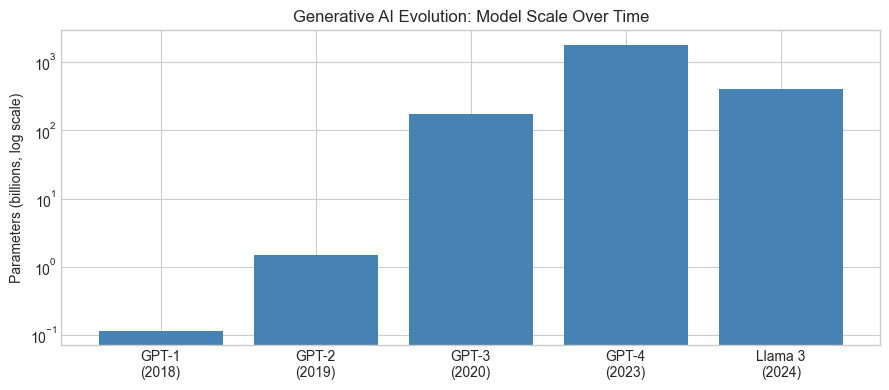

In [2]:
# Timeline visualization: model scale growth (parameters, log scale)

models = ["GPT-1\n(2018)", "GPT-2\n(2019)", "GPT-3\n(2020)", "GPT-4\n(2023)", "Llama 3\n(2024)"]
params_b = [0.117, 1.5, 175, 1800, 405]  # approximate billions

plt.figure(figsize=(9, 4))
plt.bar(models, params_b, color="steelblue")
plt.yscale("log")
plt.ylabel("Parameters (billions, log scale)")
plt.title("Generative AI Evolution: Model Scale Over Time")
plt.tight_layout()
plt.show()

---

## 5. Overview of Generative AI Models

Several architectural families power modern generative AI. Each learns data distributions differently and suits different modalities.

| Family | Core Idea | Best For | Covered In |
|--------|-----------|----------|------------|
| **Autoregressive** | Predict next element sequentially | Text, code, sequences | Notebooks 02, 06, 07 |
| **GAN** | Generator vs discriminator competition | Sharp images, style transfer | Notebook 03 |
| **Autoencoder / VAE** | Compress to latent space, decode samples | Representation learning, smooth generation | Notebook 04 |
| **Diffusion** | Iterative denoising from random noise | High-quality images | Notebook 02 (overview) |
| **Transformer** | Self-attention over sequences | Language models, multimodal | Notebook 05 |

These families are not mutually exclusive. Diffusion models use transformer backbones. Multimodal systems combine autoregressive text generation with diffusion image heads. The next notebooks explore each family in depth, starting with probability foundations and model types.

---

## 6. Modalities and Multimodal Generation

Generative AI operates across multiple **modalities** — types of data:

**Text** — Language models generate essays, emails, code, summaries, and dialogue through autoregressive next-token prediction.

**Images** — Diffusion models and GANs generate images from text prompts, perform editing, and transfer styles.

**Audio** — Text-to-speech and music generation models synthesize sound from learned acoustic patterns.

**Video** — An emerging frontier combining spatial (image) and temporal (sequence) generation.

**Multimodal** — Models like GPT-4V and Gemini accept and produce more than one data type, enabling applications such as describing images, answering questions about charts, or generating visuals from text.

---

## 7. What Generative AI Is Not

Public discussion of generative AI is often clouded by misconceptions.

**Generative AI is not understanding.** Language models process statistical patterns in text. They do not comprehend meaning or hold beliefs the way humans do.

**Generative AI is not search.** A chatbot generates responses from learned patterns; it does not look up answers in a database unless connected to external retrieval tools.

**Generative AI is not deterministic.** The same input can produce different outputs because generation involves sampling from a probability distribution.

**Generative AI is not a replacement for domain expertise.** Generated medical, legal, or financial content requires human verification.

**Generative AI is not one model.** The field encompasses diverse architectures, modalities, and deployment scales under one umbrella term.

---

## 8. Summary and Learning Path

**Generative AI** is a paradigm in which machine learning models learn data distributions and synthesize new content. It builds on machine learning and deep learning foundations, evolving from statistical models through GANs and VAEs to transformer-based systems at scale.

The notebooks in this section follow a structured path:

1. **Introduction to Generative AI** — basics, evolution, ML relationship (this notebook)
2. **Generative AI Models and Probability** — discriminative vs generative, probability, MLE
3. **Generative Adversarial Networks** — GAN architecture, training, applications
4. **Autoencoders and Variational Autoencoders** — latent space, VAEs
5. **Transformers in Generative AI** — attention, embeddings, transformer blocks
6. **How Large Language Models Work** — next-token objective, architecture, scaling
7. **Large Language Models and ChatGPT** — LLMs in practice, ChatGPT evolution
8. **Tokens and Context Windows** — tokenization, context limits, cost
9. **Inference Parameters and Text Generation** — temperature, sampling, decoding
10. **Model Families and Choosing an LLM** — comparing model options
11. **Introduction to Fine-Tuning and Alignment** — conceptual overview of training stages
12. **Generative AI Applications by Industry** — use cases across domains

Production fine-tuning, RAG, agents, and deployment patterns are covered in later sections of the curriculum.